In [1]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())

hostname = Mac
threads = 1
workers = 1
BLAS threads = 4


In [2]:
using Eliashberg
using CairoMakie

## 1D Tight-Binding model 

In [3]:
lattice= ChainLattice(1.5) # 晶格常数 1.5 的一维链
kgrid = generate_reciprocal_lattice(lattice, 2000)

tb = TightBinding(lattice, 1.0, -0.3)

TightBinding{1}(ChainLattice(1.5, [1.5;;]), Tuple{StaticArraysCore.SVector{1, Int64}, Float64}[([1], -1.0)], -0.3)

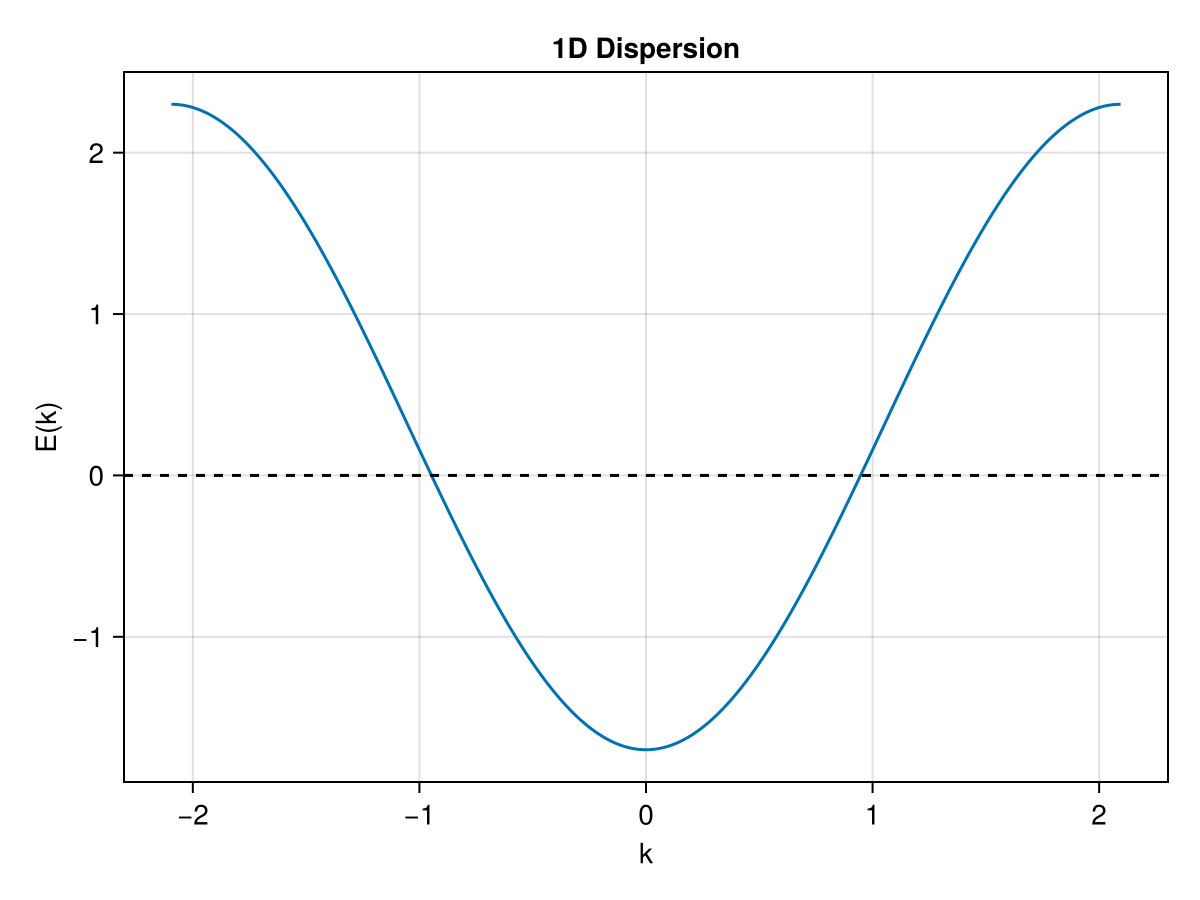

In [6]:
band_data = compute_band_data(tb, generate_kpath(lattice; n_pts_per_segment=100))
f = plot(band_data)
save("tb_1d_eband.png", f)
f


### BCS reduced Hamiltonian


In [7]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)     # 温度扫描范围 (从极低温到超过 Tc)

kpath = generate_kpath(lattice; n_pts_per_segment=50)


KPath{1}(StaticArraysCore.SVector{1, Float64}[[0.0], [0.041887902047863905], [0.08377580409572781], [0.1256637061435917], [0.16755160819145562], [0.20943951023931953], [0.2513274122871834], [0.2932153143350474], [0.33510321638291124], [0.37699111843077515]  …  [1.71740398396242], [1.759291886010284], [1.801179788058148], [1.843067690106012], [1.8849555921538759], [1.9268434942017396], [1.9687313962496034], [2.0106192982974673], [2.0525072003453313], [2.0943951023931953]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 51], ["Γ", "X"])

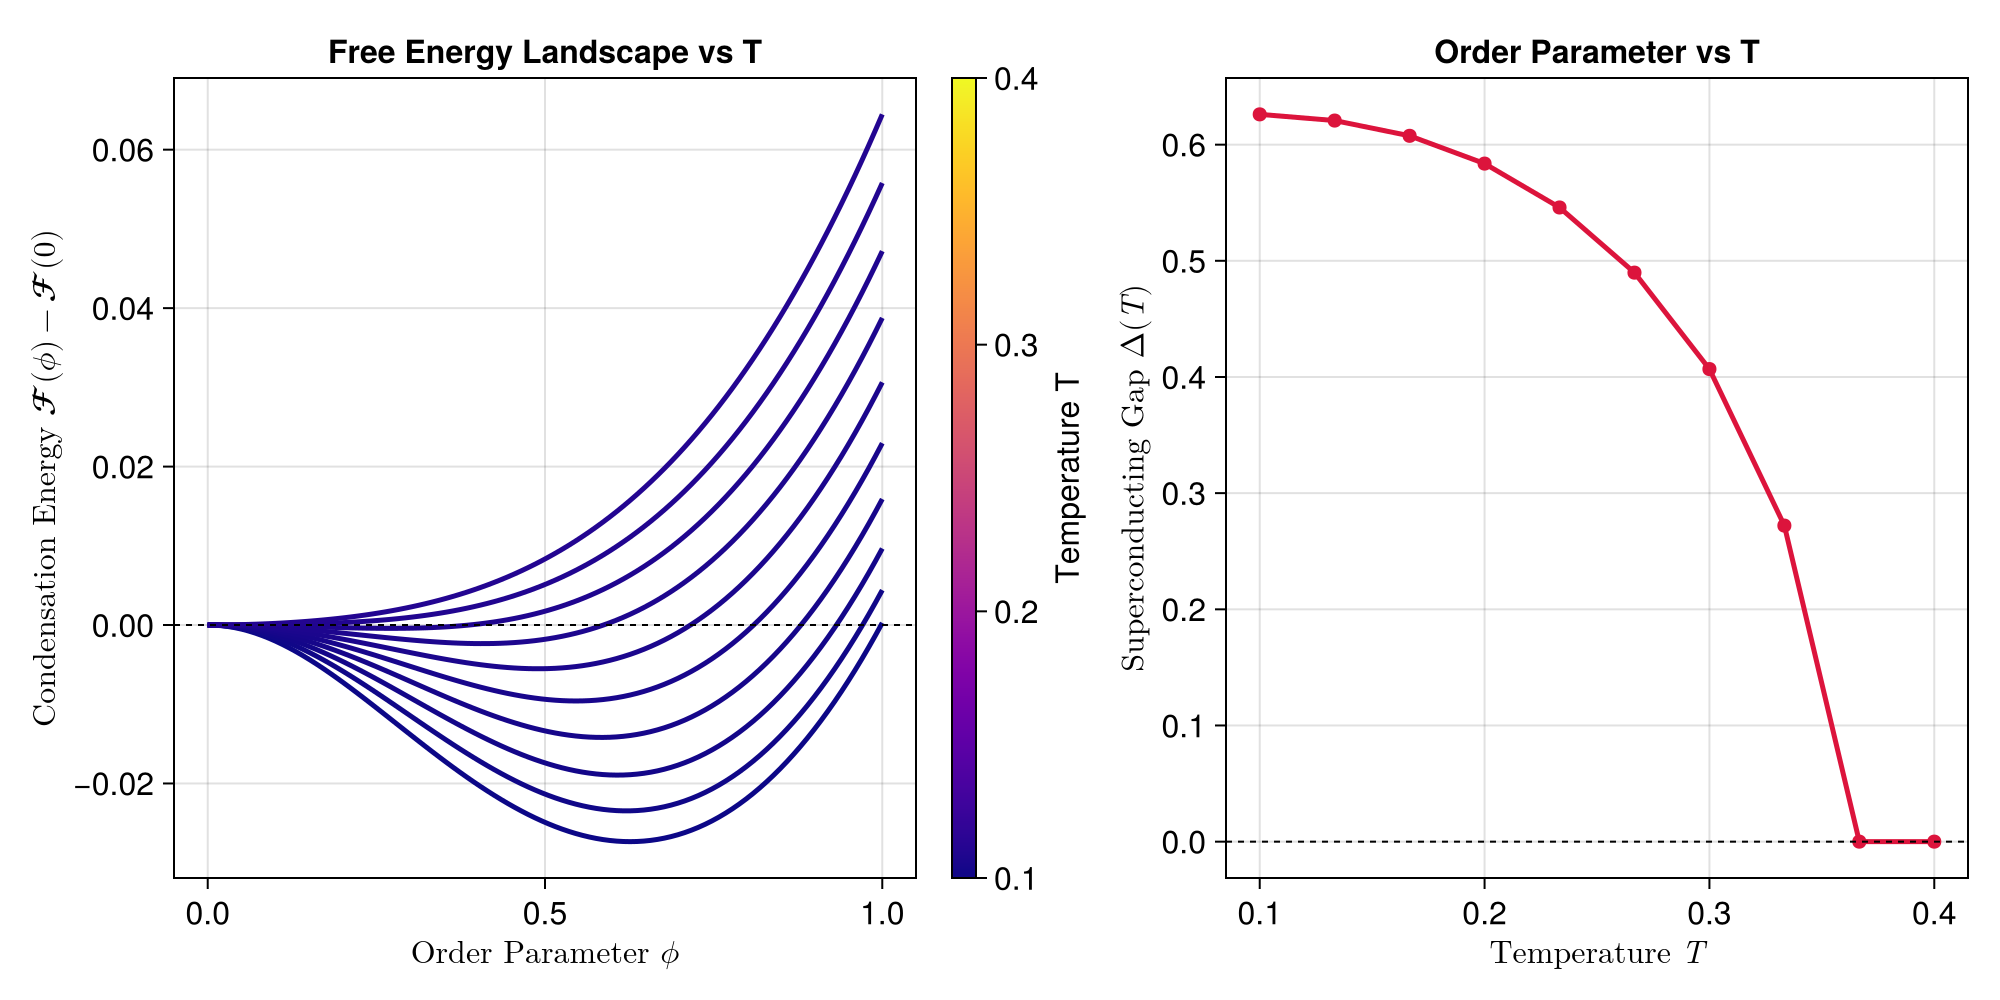

In [8]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, kpath)
plot(band_data)


In [ ]:
T_val = 0.1
collective_data = compute_collective_mode_spectral_data(T_val, sc_field, tb, interaction, kgrid, kpath; eta=0.015)
plot(collective_data)


### FFLO Pairing

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

# 设定环境参数
T_val = 0.01
h_val = 0.5 # 施加一个 Zeeman 磁场 (注意：h 必须小于裸能隙，但在 Pauli 极限附近)

# 2. 设定我们要扫描的 q 范围 (沿着 qx 方向)
q_vals = range(0.0, 1.0, length=300) # 扫描 0 到 1.0 的动量

zeeman_data = compute_zeeman_pairing_data(T_val, h_val, q_vals, tb, interaction, kgrid)
plot_zeeman_pairing_landscape(q_vals, zeeman_data.condensation_energy, zeeman_data.optimal_gaps; minimum_index=zeeman_data.minimum_index)

## 2D Tight-Binding model


### BCS reduced Hamiltonian

In [3]:

lattice = SquareLattice(1.5)
tb = TightBinding(lattice, 1.0, 0.0)

kgrid = generate_reciprocal_lattice(lattice, 50, 50)

path = generate_kpath(lattice; n_pts_per_segment=50)

KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.041887902047863905, 0.0], [0.08377580409572781, 0.0], [0.1256637061435917, 0.0], [0.16755160819145562, 0.0], [0.20943951023931953, 0.0], [0.2513274122871834, 0.0], [0.2932153143350474, 0.0], [0.33510321638291124, 0.0], [0.37699111843077515, 0.0]  …  [0.37699111843077526, 0.37699111843077526], [0.3351032163829113, 0.3351032163829113], [0.29321531433504733, 0.29321531433504733], [0.25132741228718336, 0.25132741228718336], [0.2094395102393194, 0.2094395102393194], [0.16755160819145565, 0.16755160819145565], [0.1256637061435919, 0.1256637061435919], [0.08377580409572793, 0.08377580409572793], [0.04188790204786397, 0.04188790204786397], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 51, 101, 151], ["Γ", "X", "M", "Γ"])

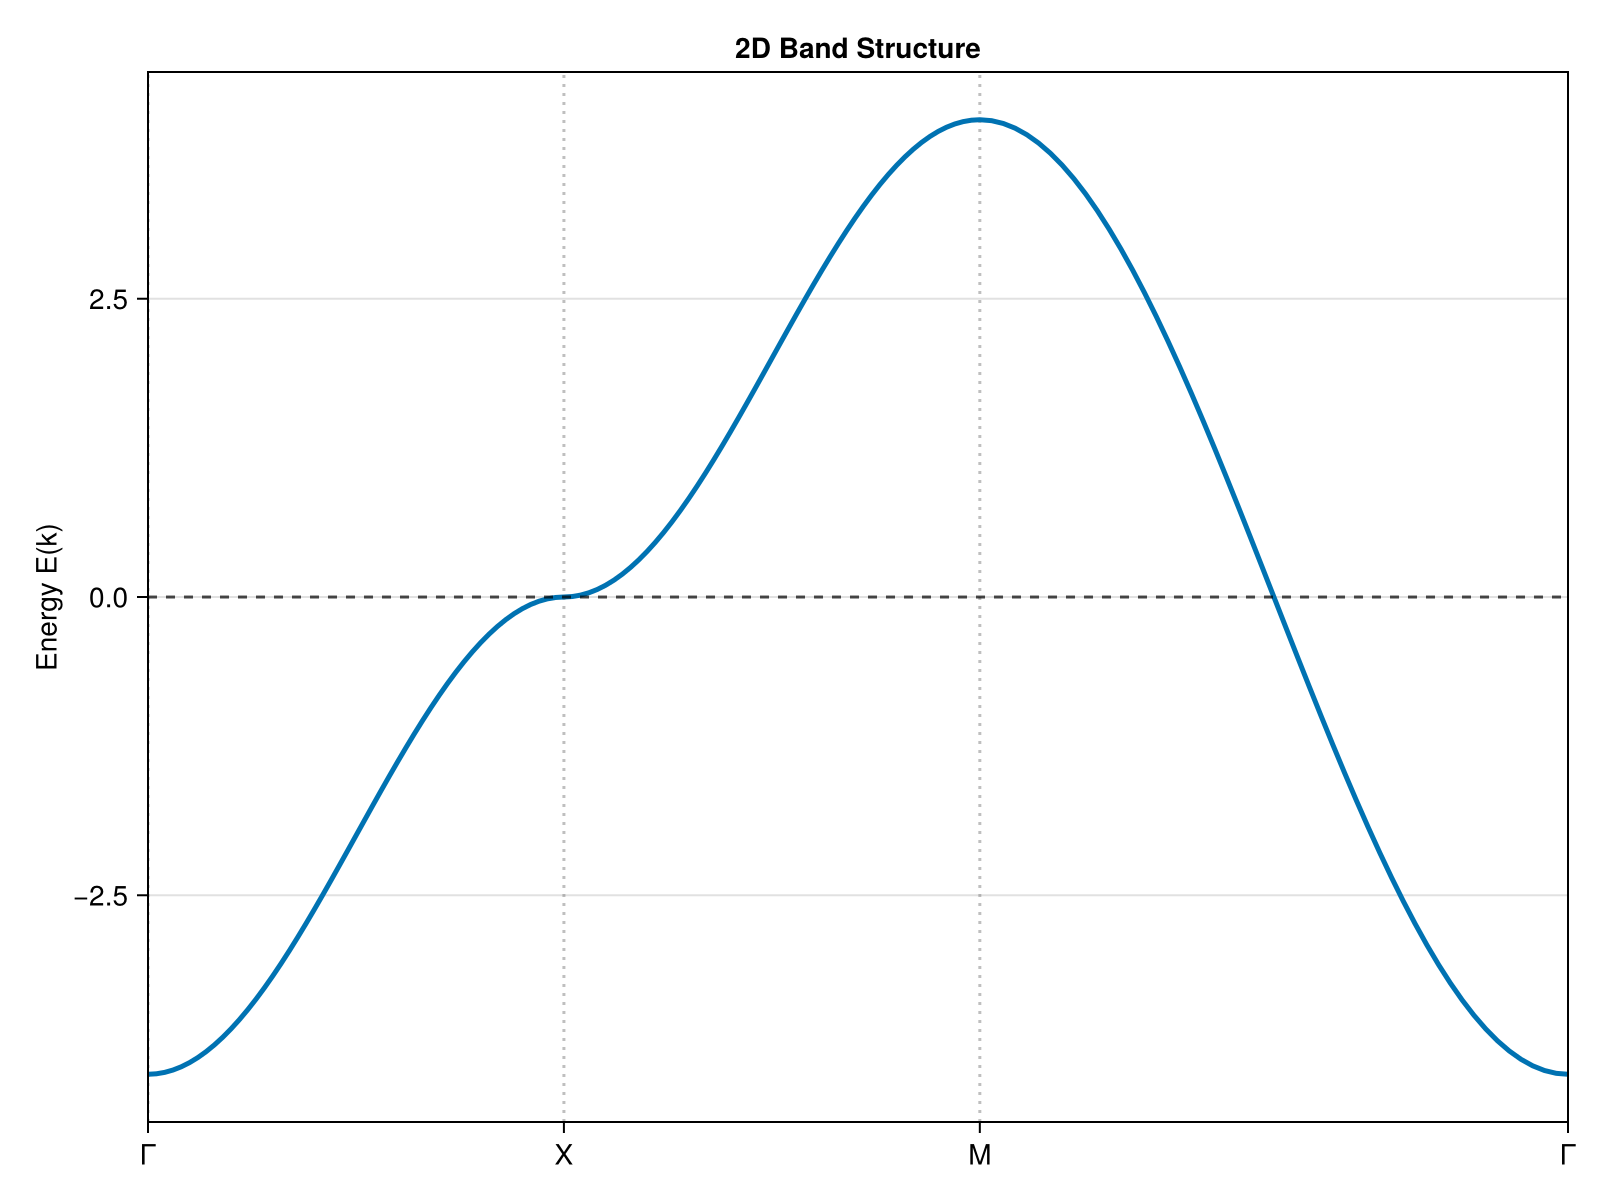

In [5]:
band_data = compute_band_data(tb, path)
plot(band_data)


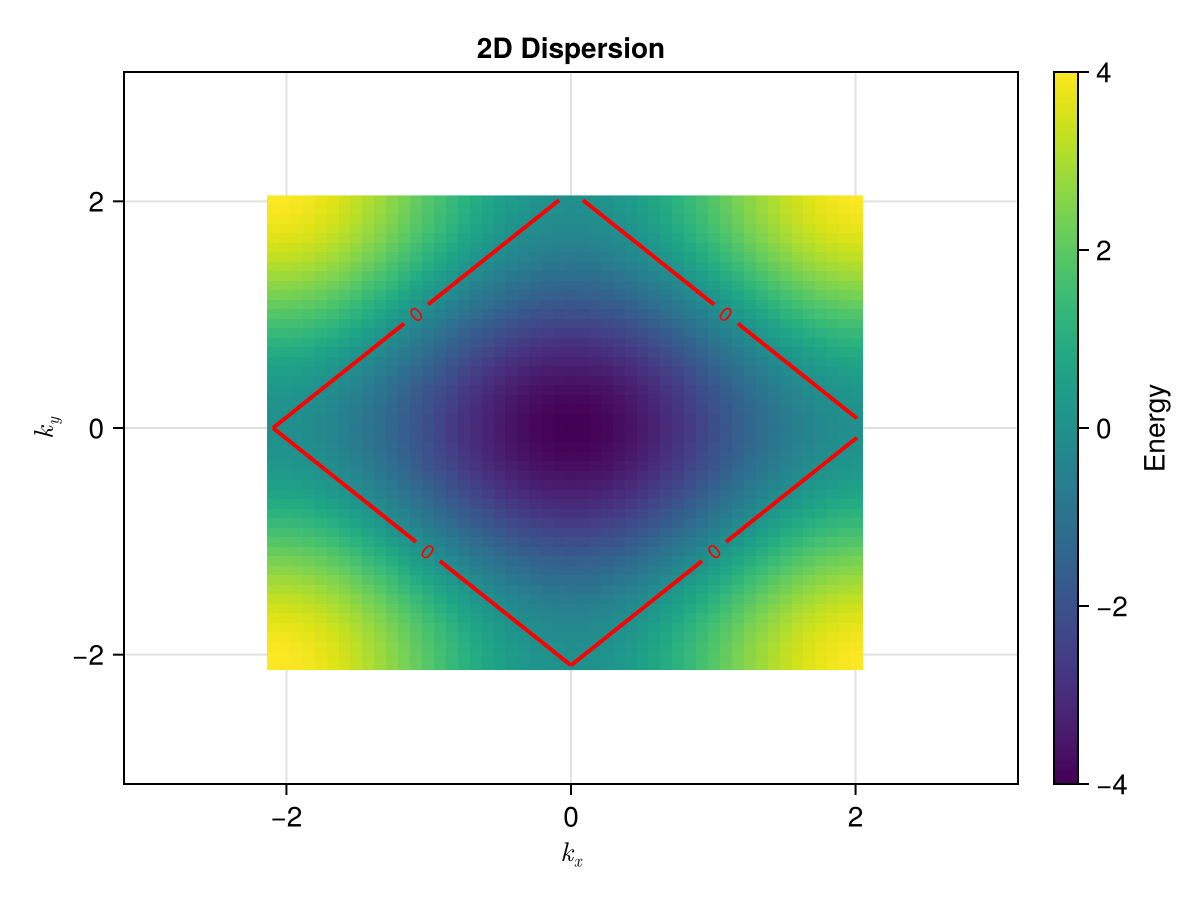

In [6]:
dispersion_data = compute_dispersion_surface_data(tb, kgrid)
f = plot_dispersion_surface(dispersion_data.kxs, dispersion_data.kys, dispersion_data.energy_matrix)
save("tb_2d_eband.png", f)
f


#### s-wave

In [6]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)



0.1:0.03333333333333333:0.4

In [8]:
k_node = (π/2, π/2)
bcs_model = MeanFieldDispersion(tb, sc_field, 0.15)
H_node = ε(k_node, bcs_model)

2×2 Hermitian{Float64, StaticArraysCore.SMatrix{2, 2, Float64, 4}} with indices SOneTo(2)×SOneTo(2):
 2.82843   0.15
 0.15     -2.82843

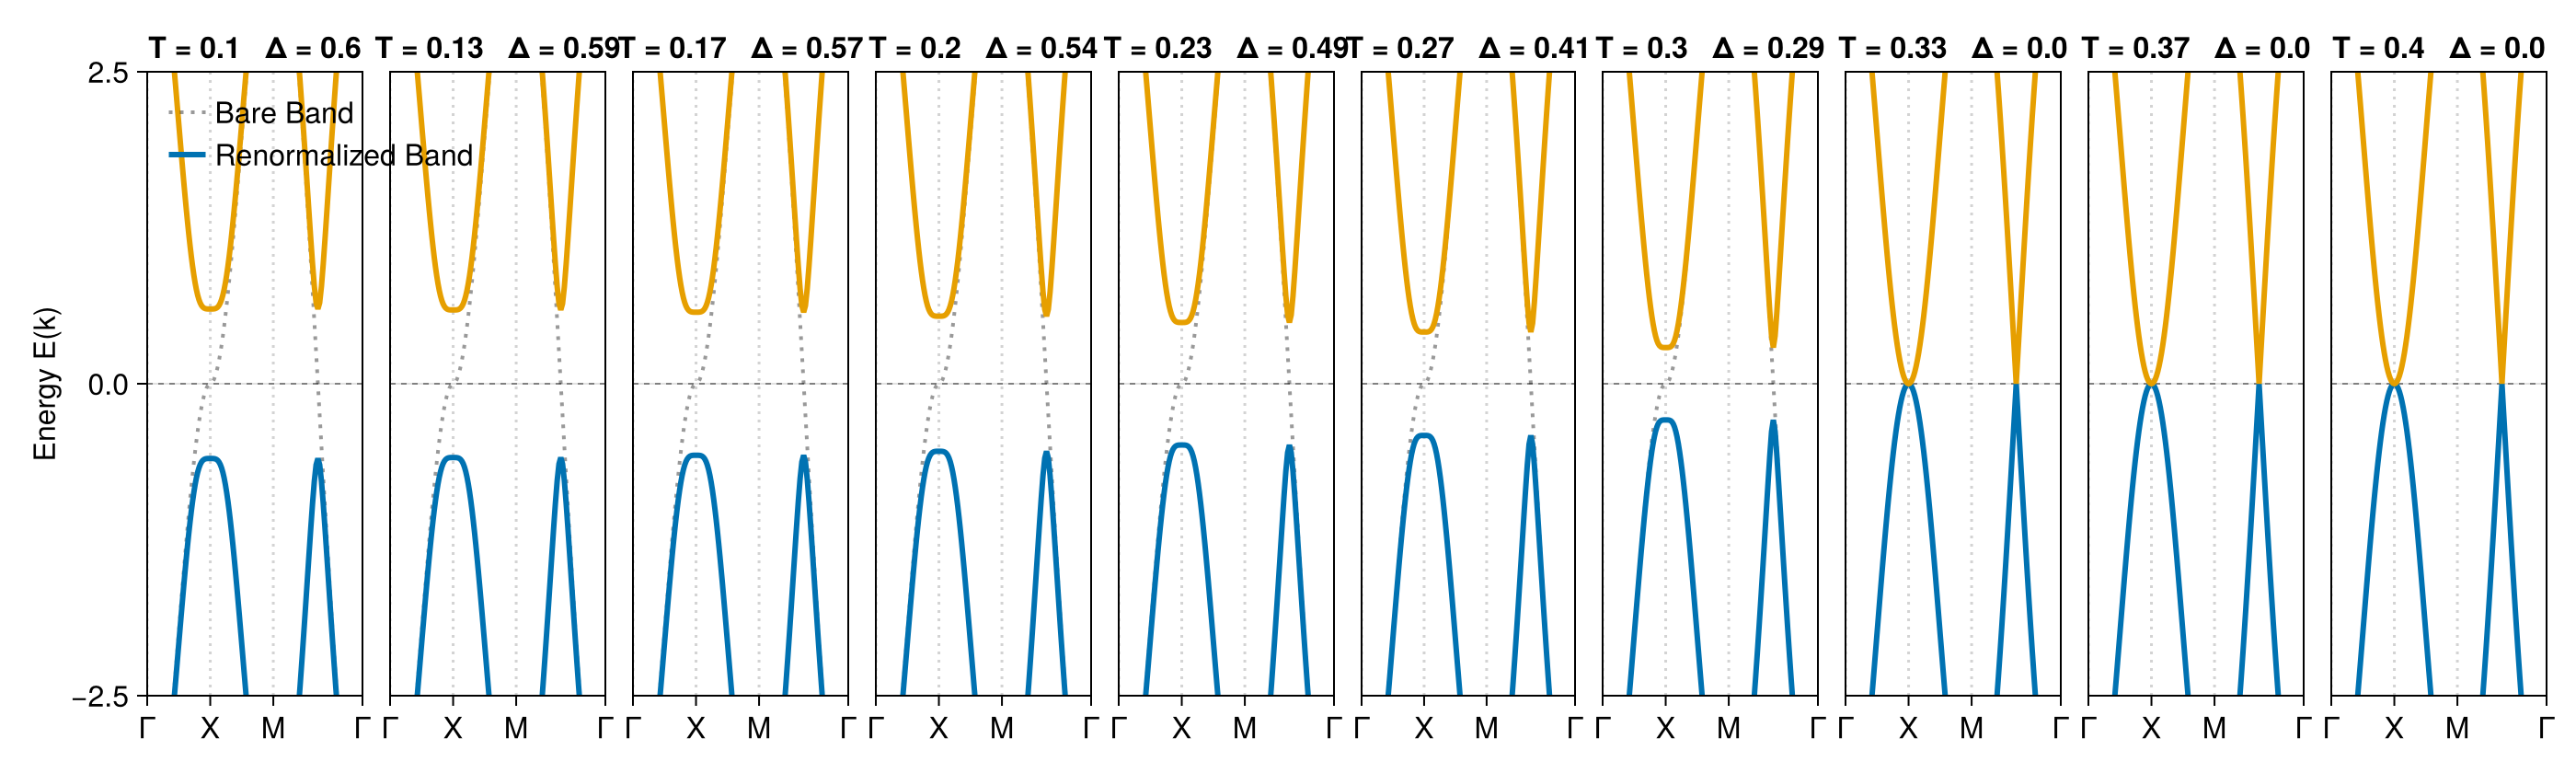

In [10]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)

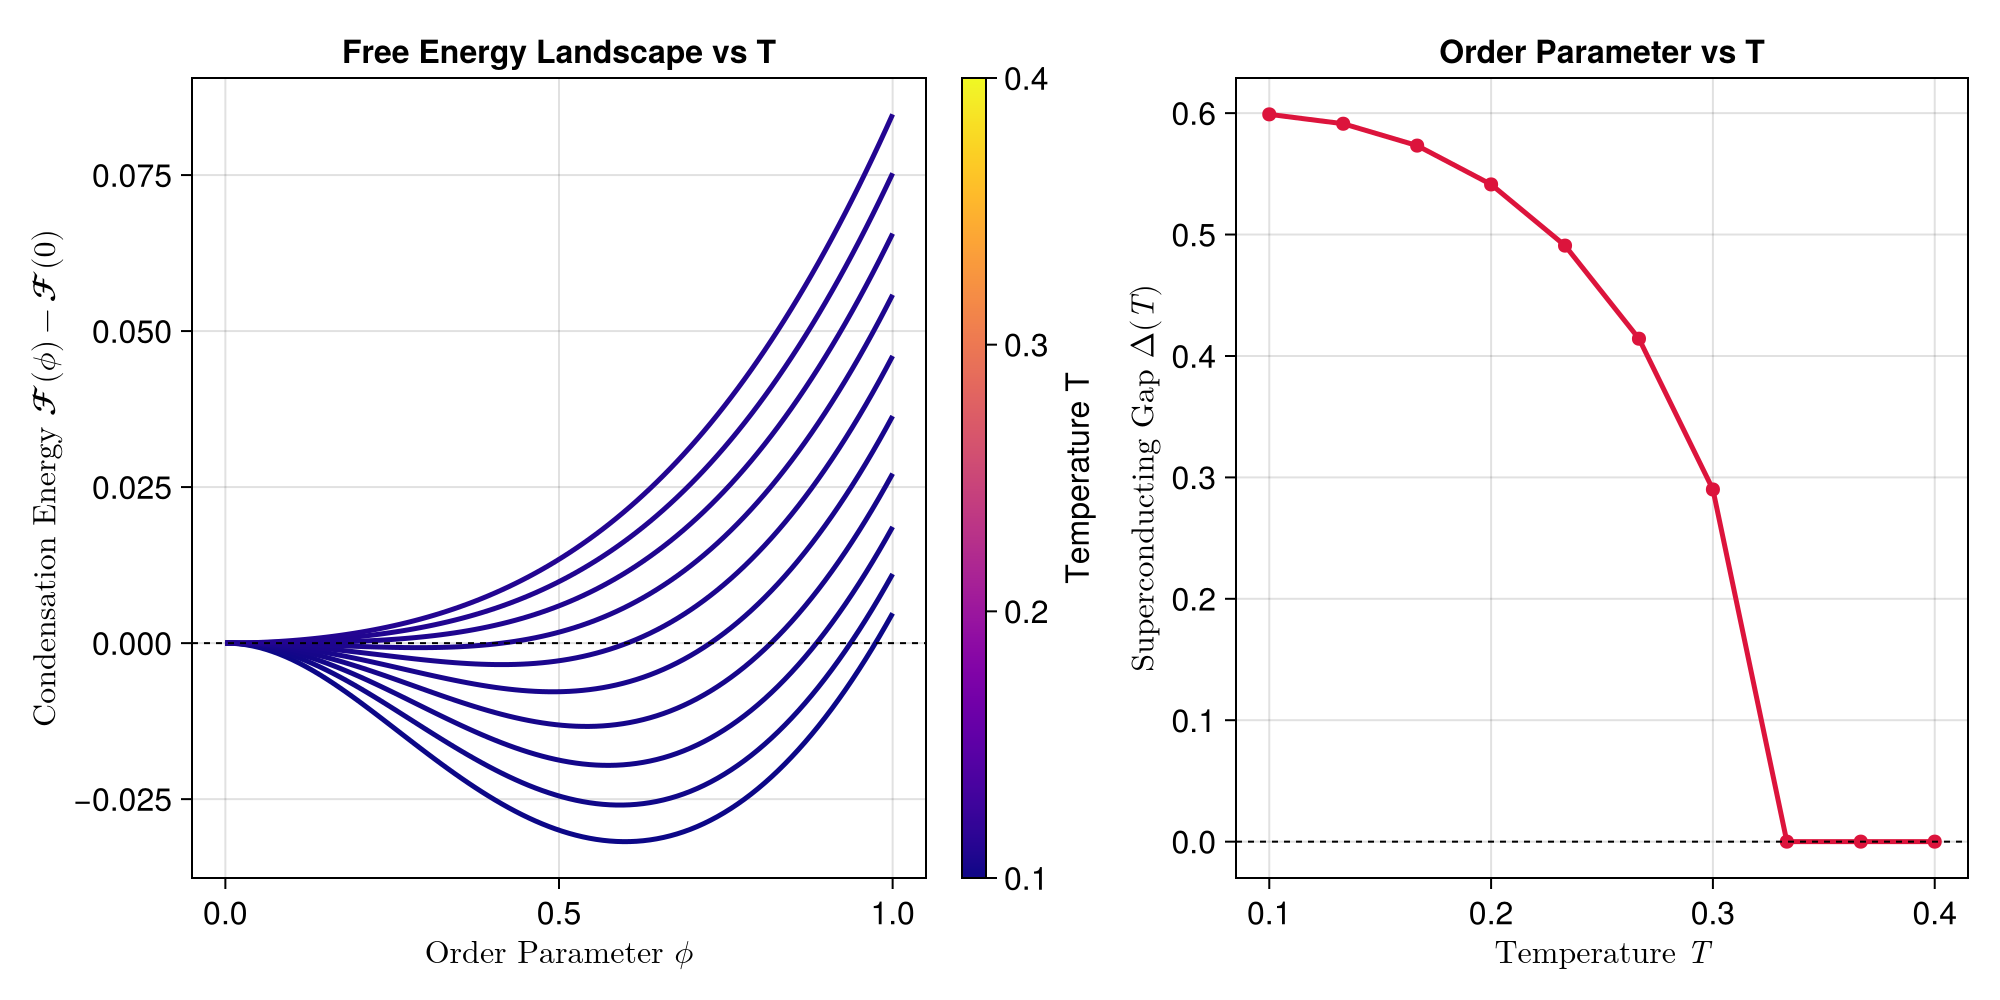

In [11]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


#### $s_{\pm}$ wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-5)

sc_field = BCSReducedPairing(:s_plus_minus_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)

In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### p-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:p_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.5, length=10)   # 温度扫描范围 (从极低温到超过 Tc)


In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### d-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-3.5)

sc_field = BCSReducedPairing(:d_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.5, length=10)   # 温度扫描范围 (从极低温到超过 Tc)

In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


### Competition with CDW

### Competition with SDW

In [8]:
tb_spinor = SpinorDispersion(tb)
interaction_U = ConstantInteraction(2.5) # 这里可以换成你更复杂的库仑/吸引相互作用

# 2. 定义你想让它们竞争的两个场 (这里强烈建议先 SDW，后 BCS)
sdw_field = SpinDensityWave((π, π), :z)

# 3. 🌟 终极合体：构造 CompositeField
coex_field = CompositeField(sdw_field, sc_field)

CompositeField{Tuple{SpinDensityWave{2, :z}, BCSReducedPairing}}((SpinDensityWave{2, :z}([3.141592653589793, 3.141592653589793]), BCSReducedPairing(:s_wave)))

In [9]:
Ts = range(0.01, 0.1, length=10)

0.01:0.01:0.1

In [12]:
k_node = (π/2, π/2)
coex_model = MeanFieldDispersion(tb, coex_field)
H_node = ε(k_node, coex_model)

LoadError: MethodError: no method matching MeanFieldDispersion(::TightBinding{2}, ::CompositeField{Tuple{SpinDensityWave{2, :z}, BCSReducedPairing}})
The type `MeanFieldDispersion` exists, but no method is defined for this combination of argument types when trying to construct it.

[0mClosest candidates are:
[0m  MeanFieldDispersion(::M, ::F, [91m::Float64[39m) where {D, M<:ElectronicDispersion{D}, F<:AuxiliaryField}
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Responses/[39m[90m[4mmean_field.jl:6[24m[39m
[0m  MeanFieldDispersion(::M, ::F, [91m::Real[39m) where {D, M<:ElectronicDispersion{D}, F<:AuxiliaryField}
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Responses/[39m[90m[4mmean_field.jl:31[24m[39m
[0m  MeanFieldDispersion(::ElectronicDispersion, ::CompositeField, [91m::AbstractVector{<:Real}[39m)
[0m[90m   @[39m [35mEliashberg[39m [90m~/Developer/theory/Eliashberg/src/Responses/[39m[90m[

In [10]:
guesses = [0.3, 0.1]

band_data = compute_renormalized_band_data(
    Ts, 
    coex_field,     # 传入复合场
    tb_spinor, 
    interaction_U, 
    kgrid, 
    path; 
    phi_guess=guesses # 传入向量初猜
)

RenormalizedBandData{2, Matrix{Float64}}(KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.041887902047863905, 0.0], [0.08377580409572781, 0.0], [0.1256637061435917, 0.0], [0.16755160819145562, 0.0], [0.20943951023931953, 0.0], [0.2513274122871834, 0.0], [0.2932153143350474, 0.0], [0.33510321638291124, 0.0], [0.37699111843077515, 0.0]  …  [0.37699111843077526, 0.37699111843077526], [0.3351032163829113, 0.3351032163829113], [0.29321531433504733, 0.29321531433504733], [0.25132741228718336, 0.25132741228718336], [0.2094395102393194, 0.2094395102393194], [0.16755160819145565, 0.16755160819145565], [0.1256637061435919, 0.1256637061435919], [0.08377580409572793, 0.08377580409572793], [0.04188790204786397, 0.04188790204786397], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 51, 101, 151], ["Γ", "X", "M", "Γ"]), [-4.0 -4.0; -3.996053456856543 -3.996053456856543; … ; -3.9921069137130862 -3.9921069137130862; -4

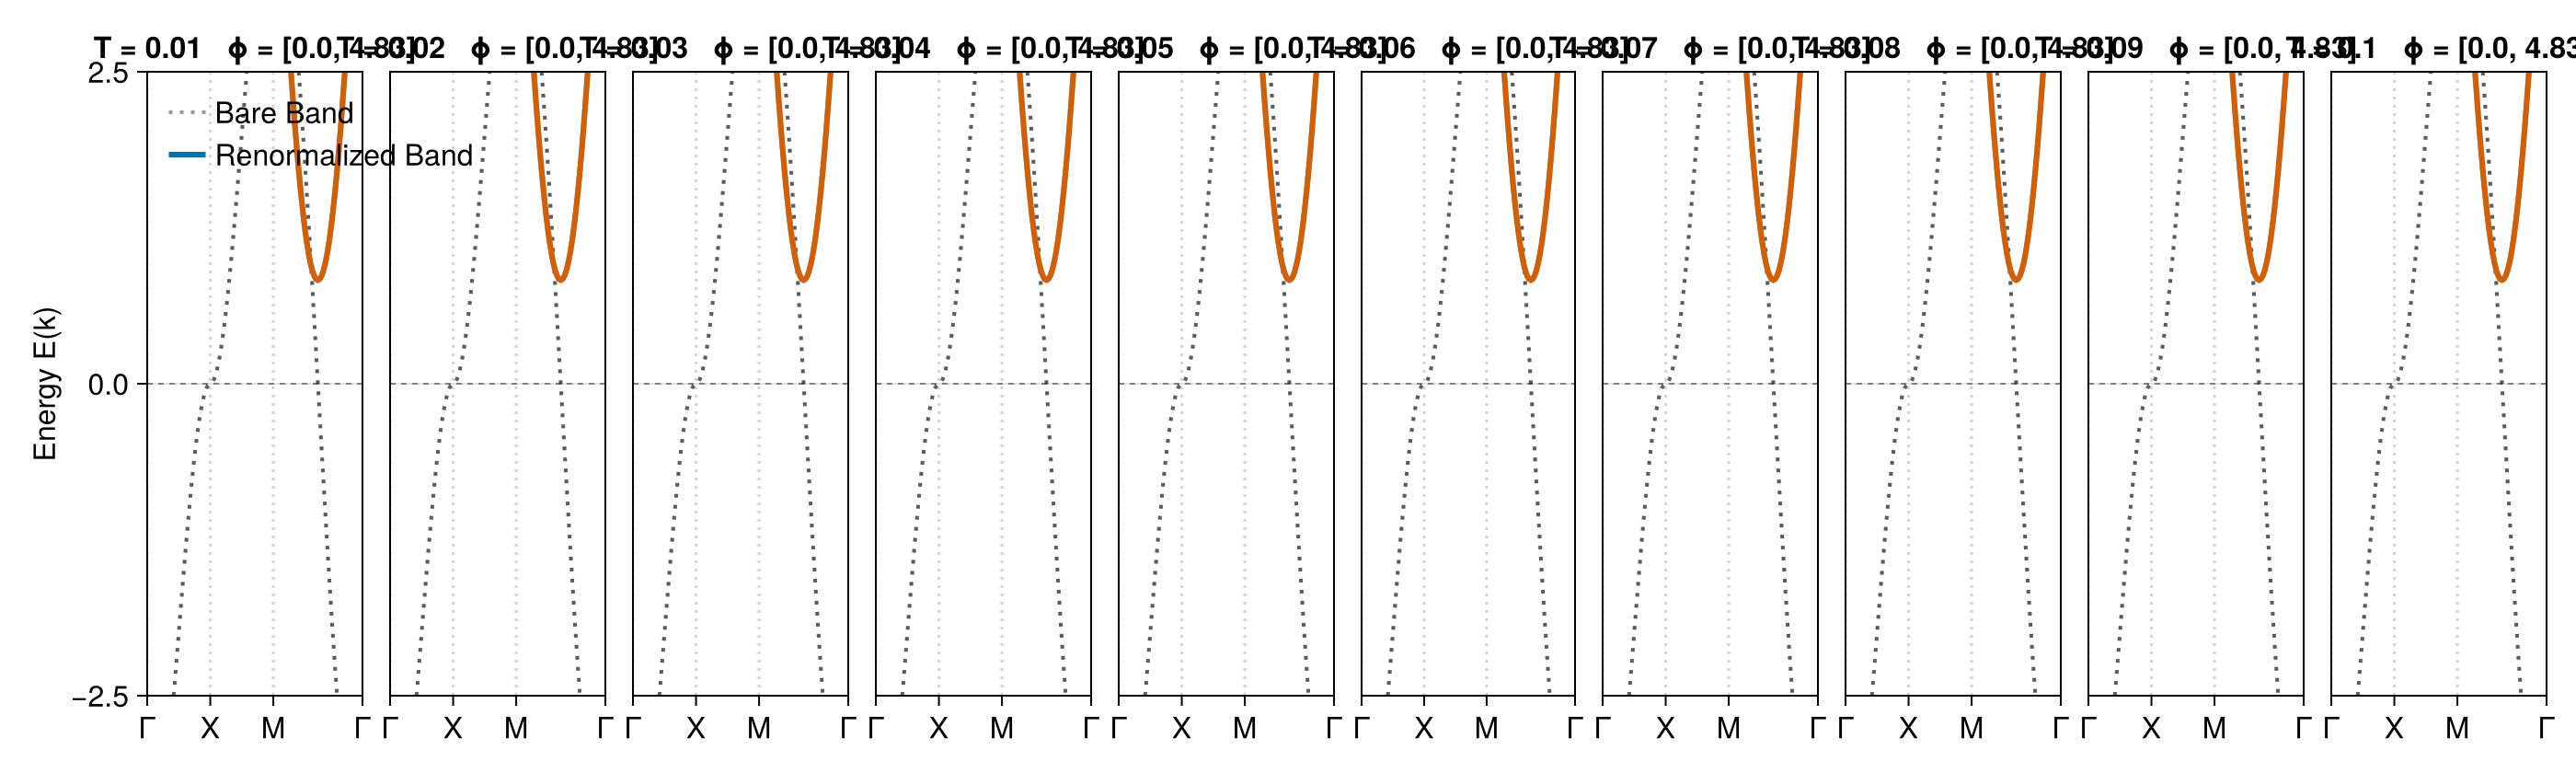

In [11]:
plot(band_data)

## 3D Tight-Binding model

In [ ]:
lattice = CubicLattice(1.5)
tb = TightBinding(lattice, 1.0, 0.0)

kgrid = generate_reciprocal_lattice(lattice, 20, 20, 20)

path = generate_kpath(lattice; n_pts_per_segment=20)



In [ ]:
band_data = compute_band_data(tb, path)
f = plot(band_data)
save("tb_3d_eband_GXMGR.png", f)
f


In [ ]:
# fermi_surface = compute_fermi_surface_volume(tb; n_pts=60)
# f = plot_fermi_surface(fermi_surface.kxs, fermi_surface.kys, fermi_surface.kzs, fermi_surface.energy_volume; E_Fermi=0.0)
# save("tb_3d_eband_fs.png", f)


In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)


In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)
